In [1]:
import pandas as pd
df = pd.read_csv("rr_vs_dc_ipl2026.csv")
print(df.shape)
print(df.head())

(239, 9)
   innings batting_team bowling_team  over  ball bowler  batsman  \
0        1           RR           DC     0     1  Starc  Jaiswal   
1        1           RR           DC     0     2  Starc  Jaiswal   
2        1           RR           DC     0     3  Starc  Jaiswal   
3        1           RR           DC     0     4  Starc    Jurel   
4        1           RR           DC     0     5  Starc    Jurel   

                                          commentary  runs  
0  Jaiswal SIX! Swivel pull over backward square ...     6  
1  Length around off, Jaiswal looks to cut, goes ...     0  
2  OUT! Jaiswal caught and bowled Starc. Full tos...     0  
3  Fullish ball on off, Jurel defends to mid-on. ...     0  
4  Poke and a miss! 143ks hard length, Jurel open...     0  


In [2]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
#creaated object
sentiments_commentry = SentimentIntensityAnalyzer()

def cricket_score(line):
    keywords = {
        "SIX": +0.5, "FOUR": +0.3,
        "WICKET": -0.5, "OUT": -0.5, "DOT": -0.2
    }
    score = 0
    for word, value in keywords.items():
        if word in line.upper():
            score += value
    return score

In [3]:
#For each commentary line, run VADER and grab only the compound score
df["vader_score"] = df["commentary"].apply(lambda x: sentiments_commentry.polarity_scores(x)["compound"])
#You have a custom function cricket_score that gives extra points based on cricket words.
df["cricket_score"] = df["commentary"].apply(cricket_score)
#Add both scores together. This is your hybrid sentiment.
df["final_score"] = df["vader_score"] + df["cricket_score"]

print(df[["commentary", "vader_score", "cricket_score", "final_score"]].head(10))

                                          commentary  vader_score  \
0  Jaiswal SIX! Swivel pull over backward square ...       0.0000   
1  Length around off, Jaiswal looks to cut, goes ...      -0.2732   
2  OUT! Jaiswal caught and bowled Starc. Full tos...       0.3578   
3  Fullish ball on off, Jurel defends to mid-on. ...       0.0000   
4  Poke and a miss! 143ks hard length, Jurel open...      -0.3164   
5  Jurel punches fullish ball to mid-off for quic...       0.0000   
6  Pitched up outside off, Jurel punches to cover...       0.0000   
7  Back of length on off, Jurel dances down, shap...      -0.6360   
8  Length around off, defended towards cover poin...       0.0000   
9  FOUR! Slow half-volley, Sooryavanshi drives st...       0.7339   

   cricket_score  final_score  
0            0.5       0.5000  
1           -0.2      -0.4732  
2           -1.0      -0.6422  
3           -0.2      -0.2000  
4            0.0      -0.3164  
5            0.0       0.0000  
6           -0.7

In [4]:


over_sentiment = df.groupby(["innings", "over"])["final_score"].mean().reset_index()
over_sentiment.columns = ["innings", "over", "avg_sentiment"]
print(over_sentiment.head(20))

    innings  over  avg_sentiment
0         1     0      -0.188633
1         1     1      -0.250350
2         1     2      -0.274667
3         1     3      -0.176583
4         1     4      -0.308733
5         1     5       0.057683
6         1     6      -0.226467
7         1     7      -0.096417
8         1     8      -0.160433
9         1     9      -0.005867
10        1    10      -0.013633
11        1    11       0.026333
12        1    12      -0.275983
13        1    13      -0.090217
14        1    14       0.113683
15        1    15       0.118850
16        1    16      -0.169450
17        1    17       0.225633
18        1    18      -0.145417
19        1    19      -0.087683


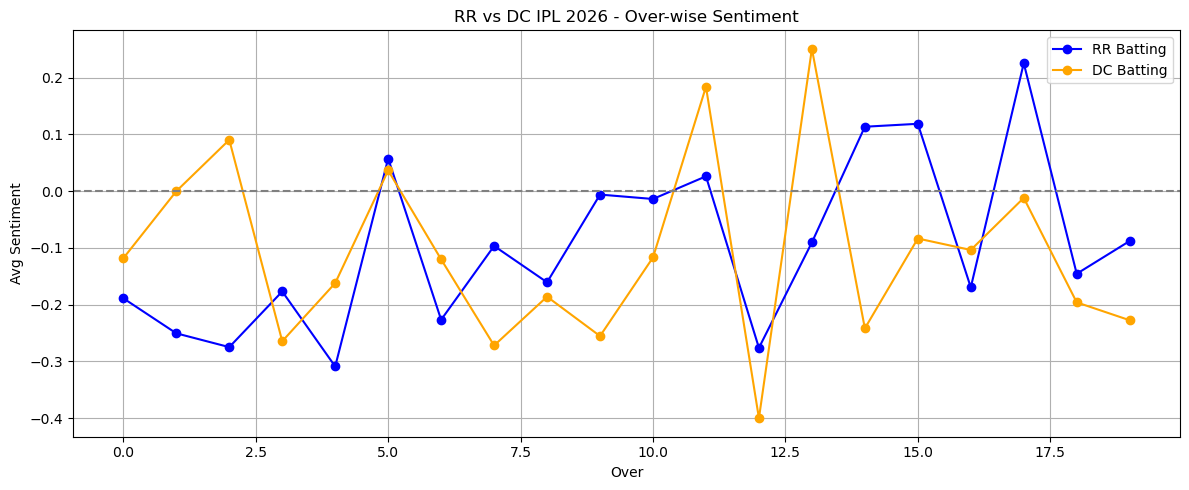

In [5]:
import matplotlib.pyplot as plt

innings1 = over_sentiment[over_sentiment["innings"] == 1]
innings2 = over_sentiment[over_sentiment["innings"] == 2]

plt.figure(figsize=(12, 5))
plt.plot(innings1["over"], innings1["avg_sentiment"], 
         marker="o", label="RR Batting", color="blue")
plt.plot(innings2["over"], innings2["avg_sentiment"], 
         marker="o", label="DC Batting", color="orange")
# draws a horizontal line across the entire plot.
plt.axhline(y=0, color="gray", linestyle="--")
plt.title("RR vs DC IPL 2026 - Over-wise Sentiment")
plt.xlabel("Over")
plt.ylabel("Avg Sentiment")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
#feature engineering

def get_features(group):
    avg_sent = group["final_score"].mean()
    wickets = group["commentary"].str.upper().str.contains("OUT").sum()
    boundaries = group["commentary"].str.upper().str.contains("SIX|FOUR").sum()
    dots = group["commentary"].str.upper().str.contains("DOT").sum()
    return pd.Series({
        "avg_sentiment": avg_sent,
        "wicket_count": wickets,
        "boundary_count": boundaries,
        "dot_count":dots
    })

In [10]:
features_df = df.groupby(["innings", "over"]).apply(get_features).reset_index()
print(features_df.head(10))

   innings  over  avg_sentiment  wicket_count  boundary_count  dot_count
0        1     0      -0.188633           1.0             1.0        2.0
1        1     1      -0.250350           3.0             1.0        2.0
2        1     2      -0.274667           2.0             2.0        2.0
3        1     3      -0.176583           2.0             1.0        1.0
4        1     4      -0.308733           1.0             1.0        2.0
5        1     5       0.057683           0.0             3.0        0.0
6        1     6      -0.226467           0.0             1.0        1.0
7        1     7      -0.096417           1.0             0.0        0.0
8        1     8      -0.160433           2.0             2.0        2.0
9        1     9      -0.005867           0.0             0.0        1.0


C:\Users\vighn\AppData\Local\Temp\ipykernel_17912\3200178519.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby(["innings", "over"]).apply(get_features).reset_index()
